Build an image classification model using a pretrained CNN and apply transfer learning to CIFAR-10. Compare feature extraction and fine-tuning with a CNN trained from scratch to understand how pretrained models can improve performance and reduce training effort.

For Project B, we'll use CIFAR-10 again initially so that you can directly compare this project with your Project A.

In [4]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
#Import TensorFlow and CIFAR-10
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

(X_train,y_train),(X_test,y_test)=cifar10.load_data()

In [3]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


Our CIFAR-10 images are:
32 × 32 × 3
We'll resize them because the pretrained model we're going to use expects a larger input.

In [6]:
#Resize the images

X_train=tf.image.resize(X_train,(96,96))
X_test=tf.image.resize(X_test,(96,96))




Now:
CIFAR-10 image
32 × 32 × 3
      ↓
96 × 96 × 3

In [7]:
#Load MobileNetV2 with pretrained weights

from tensorflow.keras.applications import MobileNetV2

base_model=MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)

)
#9406464 is the size of the downloaded weights file in bytes.

input_shape=(96, 96, 3)
This tells MobileNetV2:
Our input images will be 96 × 96 pixels with 3 color channels (RGB).

include_top=False
The original MobileNetV2 has:

CNN layers
   ↓
Original ImageNet classifier
   ↓
1000 classes
We don't want the original 1000-class ImageNet classifier, because our task is CIFAR-10 with 10 classes.

So:
include_top=False
means:
Remove the original classification layers and keep the pretrained CNN feature-extraction part.

include_top=False means remove the original “top” classification part of MobileNetV2 — the part that produces the 1000 ImageNet classes.
It removes the original final classification part that gives the 1000-class prediction.

Why are we importing MobileNetV2 if it's an architecture?
MobileNetV2 is an architecture, but when we write:

MobileNetV2(weights="imagenet", ...)
we are asking TensorFlow to give us:
the MobileNetV2 architecture + the pretrained ImageNet weights

So we are not using an empty MobileNetV2 architecture.
We are using:

MobileNetV2 architecture
        +
ImageNet-learned weights
        ↓
PRETRAINED MobileNetV2
That's the model we're using for transfer learning

ImageNet is a dataset. ✅
We are not saying ImageNet itself contains learned weights.

The process is:
ImageNet dataset
      ↓
Train MobileNetV2 architecture
      ↓
Model learns weights
      ↓
Save those learned weights
      ↓
Pretrained MobileNetV2

So when we write:
MobileNetV2(weights="imagenet")
"imagenet" means:

Load the MobileNetV2 weights that were previously learned by training on the ImageNet dataset.

So:
ImageNet = dataset
ImageNet-trained weights = learned weights produced from that dataset ✅

MobileNetV2 architecture
        +
weights learned by training on ImageNet
        ↓
Pretrained MobileNetV2 model
So:
MobileNetV2(weights="imagenet")
means “give me the MobileNetV2 architecture with its previously learned ImageNet weights.”

why given input shape?

Because the model needs to know what shape of images it will receive as input.

input_shape=(96, 96, 3)

means:

96 → height
96 → width
3 → RGB channels

Our CIFAR-10 images were originally:

32 × 32 × 3

We resized them to:

96 × 96 × 3

So we tell MobileNetV2:

“The images I am going to give you are 96×96 RGB images.” ✅

In [7]:
base_model.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

Input
(None, 96, 96, 3)
        ↓
many CNN layers / blocks
        ↓
feature representation

And because we used:

include_top=False
the original 1000-class classification head is not present.

In [5]:
base_model.trainable=False

base_model.trainable = False

means:This will freeze the pretrained MobileNetV2 weights so that, initially, we train only our new classifier.
Use the pretrained MobileNetV2 with its already-learned weights, but do not update those weights during our training.

We are taking the pretrained MobileNetV2 and adding a small new classifier on top of it.
Think of it like:

Pretrained MobileNetV2
(already learned visual features)
        ↓
   Feature extractor
        ↓
 NEW classifier
        ↓
  10 CIFAR-10 classes

The MobileNetV2 part is already the CNN.
The new classifier is mainly responsible for taking the features produced by MobileNetV2 and deciding:
“Which of our 10 classes does this image belong to?”

So:
New CNN from scratch ❌
Pretrained CNN + new classification head ✅
And in this first stage, the pretrained CNN is frozen, so only the new classifier learns.

We use the pretrained MobileNetV2’s already-learned weights, freeze that part so its weights do not change during training, and then train only our new classifier, whose weights are updated to learn how to map MobileNetV2’s extracted features to our 10 CIFAR-10 classes.

But, why training that new classifier again?

Because the pretrained classifier was trained for ImageNet's 1000 classes, not our CIFAR-10's 10 classes.
So we remove that old classifier and create a new one that learns:

MobileNetV2 features
        ↓
NEW classifier
        ↓
10 CIFAR-10 classes

The MobileNetV2 already knows how to extract useful visual features; the new classifier needs to learn how to use those features for our specific classes.
That's why we train the new classifier.

 We remove the pretrained model's original classification head (because it predicts 1000 ImageNet classes), then add our own new classifier for the 10 CIFAR-10 classes.

Pretrained MobileNetV2
        ↓
remove original classifier ❌
        ↓
pretrained feature extractor ✅
        ↓
add our classifier ✅
        ↓
10 CIFAR-10 classes

Are we doing a type of fine-tuning here? Tell shortly. beause we are adding our features

No. ❌

This is feature extraction, not fine-tuning.

We are adding a new classifier, but the pretrained MobileNetV2 layers remain frozen.

Fine-tuning = unfreeze some pretrained layers and train them further.

If the pretrained model had some final classification layer whose classes didn't match our task, we would replace that classification layer with our new classifier.

But if you remove a feature-extraction layer in the CNN (a Conv/BatchNorm/etc. layer), you don't automatically need another classifier.

So the key is:

Wrong final classifier → replace it. ✅
Remove a feature layer → no new classifier just because of that. ✅

In [8]:
#Now we build our new classifier on top of the frozen MobileNetV2.

from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense

feature_model=Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

Here:

base_model → pretrained MobileNetV2, whose weights are frozen.
GlobalAveragePooling2D → converts the feature maps into a smaller vector.
Dense(128) → learns from those features.
Dense(10) → our new classifier for the 10 CIFAR-10 classes.

Yes. ✅ The new classifier is the new final layer(s) we add after the pretrained MobileNetV2 to classify our 10 CIFAR-10 classes 


Think of classifier = the new part we add after MobileNetV2:

MobileNetV2 (pretrained)
        ↓
    Classifier
        ↓
   10 classes

In our code, we made that classifier using two Dense layers:

Dense(128, activation="relu")
Dense(10, activation="softmax")

Why two? The first layer processes the features, and the second layer finally chooses among the 10 classes.

In [9]:
feature_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2
(None, 3, 3, 1280)
This is the pretrained CNN.

It has 2,257,984 parameters, which are the weights it learned from ImageNet.
For now, we will keep these frozen.


GlobalAveragePooling2D
(None, 1280)

MobileNetV2 gives us a feature map of:
3 × 3 × 1280    So there are 1280 feature maps, each of size 3×3.

This layer converts that into:
1280

So it basically turns the CNN's feature maps into a 1280-number feature vector that our classifier can work with.


MobileNetV2 produces features → GlobalAveragePooling converts those features into 1280 numbers → our classifier uses those numbers.

GlobalAveragePooling2D is NOT converting 1000 classes. Because we used include_top=False, the 1000-class classifier was already removed.

Instead:

Pretrained MobileNetV2
        ↓
3 × 3 × 1280 feature maps
        ↓
GlobalAveragePooling2D
        ↓
1280-number feature vector
        ↓
Dense(128)
        ↓
Dense(10) → final 10-class output

So yes, we have our base model first, then a pooling layer, then our new Dense layer, and finally our 10-class output layer. The pooling layer simply converts the MobileNetV2 feature maps into a compact vector that our new classifier can use.

In [11]:
#right now we've built the model, but we haven't told TensorFlow how to train it yet. 

feature_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)



In [12]:
feature_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

look at trainable vs non-trainable parameters.

That is important because we want to verify:

MobileNetV2 weights → NOT updating 🔒
Our new classifier → updating ✅

Total parameters = all learnable numbers/weights in the entire model:
2,423,242 = pretrained MobileNetV2 + our new classifier.

Trainable parameters = the parameters that are allowed to change during training:
165,258 = our new classifier.  165,258 new classifier weights → trainable ✅

Non-trainable parameters = the pretrained MobileNetV2 parameters that we froze:
2,257,984.

And yes, feature extraction means we're using the features learned by the pretrained MobileNetV2 and passing those features to our new classifier. We are not changing the pretrained features in this stage; we're using them as they are.
One tiny correction: we're not only "extracting features" from the final layer. The whole frozen MobileNetV2 feature-extraction part processes the image and produces useful features, which our new classifier then uses.

In [13]:
#Now we train it.
#Before that, one important preprocessing step: MobileNetV2 expects its own input scaling, so we'll use its preprocessing function rather than simply dividing by 255.
#preprocess_input → matches MobileNetV2's expected input format.

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
#X_train=preprocess_input(X_train)
#X_test=preprocess_input(X_test)



The memory problem is NOT because ImageNet is large.
We are not loading ImageNet.
ImageNet was used earlier to train MobileNetV2. We only downloaded its learned weights.
Your memory problem happened because we resized all 50,000 CIFAR-10 images to 96×96 float32 and kept them in RAM:

50,000 × 96 × 96 × 3 × 4 bytes
≈ 5.53 GB
That's why preprocessing the entire tensor again caused the OOM.


That means:

use the first 10,000 training images
use the first 2,000 test images
we are now preprocessing those smaller portions instead of the entire        50,000-image dataset, which avoids the RAM problem.

In [9]:
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

In [10]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

X_train_small = preprocess_input(X_train_small)
X_test_small = preprocess_input(X_test_small)

I calculated it from the shape and datatype.

Your tensor is:

50,000 × 96 × 96 × 3

and float32 uses 4 bytes per number.

So:

50,000 × 96 × 96 × 3 × 4
= 5,529,600,000 bytes
≈ 5.53 GB

So your X_train itself occupies about 5.53 GB of raw memory.

That's why creating another full tensor during preprocess_input() caused the OOM (out-of-memory) error.

In [16]:
print(X_train.shape)
print(X_train.dtype)

(50000, 96, 96, 3)
<dtype: 'float32'>


In [17]:
print(X_test.shape)
print(y_test.shape)

(10000, 96, 96, 3)
(10000, 1)


The pretrained model knows the scaling it was trained with, but it does not automatically rescale new images for us.

We are giving it CIFAR-10 images, not the original ImageNet images.

So we must convert our CIFAR-10 pixel values into the same input format MobileNetV2 expects.

ImageNet training:
images → required preprocessing → MobileNetV2

Our project:
CIFAR-10 images → same preprocessing → MobileNetV2

So preprocess_input() is basically saying:

“Prepare our new images in the same format the pretrained model was trained to receive.” ✅

Why validation_data instead of validation_split?
Because:
validation_split=0.2
means:
"Take 20% of this training array and use it for validation."
Whereas:
validation_data=(X_test_small, y_test_small)

means:
"Use this separate dataset for validation."

In [18]:
feature_history=feature_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_test_small,y_test_small),
    epochs=5,
    batch_size=32
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy: 0.7790 - loss: 0.6698 - val_accuracy: 0.8420 - val_loss: 0.4747
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.8724 - loss: 0.3748 - val_accuracy: 0.8455 - val_loss: 0.4558
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9166 - loss: 0.2615 - val_accuracy: 0.8415 - val_loss: 0.4896
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - accuracy: 0.9423 - loss: 0.1874 - val_accuracy: 0.8285 - val_loss: 0.5627
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 102ms/step - accuracy: 0.9570 - loss: 0.1402 - val_accuracy: 0.8335 - val_loss: 0.5550


In [19]:
feature_model.save("feature_extraction_model.keras")
#Now you have a permanent copy of the frozen feature-extraction model.

In [20]:
print("Feature extraction model saved.")

Feature extraction model saved.


Training:
50,000 total → 10,000 used
40,000 → not used

Testing:
10,000 total → 2,000 used
8,000 → not used

The leftover data is not lost or deleted. It simply isn't being used in this first experiment.

We chose this only to avoid the memory problem while learning the transfer-learning workflow.

Later, once the basic model works, we'll go back and use the full dataset properly in batches.


The feature-extraction model was trained for 5 epochs while the MobileNetV2 base model remained completely frozen. Therefore, the pretrained MobileNetV2 weights did not change; only the newly added classifier learned from the features produced by MobileNetV2.


What do we observe?

The training accuracy continuously increased:

77.90% → 87.24% → 91.66% → 94.23% → 95.70%

However, validation accuracy reached its highest value at Epoch 2 (84.55%) and then started to decrease:

84.20% → 84.55% → 84.15% → 82.85% → 83.35%

This indicates overfitting. The classifier continued becoming better at the 10,000 training images, but its performance on the 2,000 validation images stopped improving.

Because the MobileNetV2 base model was frozen, the pretrained weights remained unchanged throughout training. The new classifier learned how to use the features extracted by MobileNetV2 to classify the CIFAR-10 images.


Therefore, this experiment demonstrates feature extraction: the pretrained CNN provides fixed learned features, while only the newly added classifier learns for the CIFAR-10 task.




And notice something interesting:

We did this while MobileNetV2 was completely frozen.

So the pretrained CNN did not learn anything new. The new classifier learned how to use the features produced by MobileNetV2.

That's exactly the feature-extraction experiment we wanted.

One important detail: we're currently using 2,000 test images as validation data, so this is not yet our final test evaluation. We should keep the remaining test images untouched for the final evaluation.

The new classifier did not take the MobileNetV2 weights. Instead:
MobileNetV2 → uses its frozen weights to extract features
New classifier → takes those extracted features, learns its own weights, and makes the prediction.

Yes. ✅ The MobileNetV2 weights stayed unchanged, and using those fixed learned weights, it extracted features. Then the new classifier used those features with its own changing weights to make predictions.

By extracted features, I mean the information/representations produced by MobileNetV2 after it processes an image.

So features are numbers that represent what the CNN has detected in the image. The MobileNetV2 uses its fixed weights to produce those features.

Inside the CNN, the image passes through many layers. Each layer performs mathematical operations and produces numbers.

For example, an early layer might produce something conceptually like:

[0.2, 1.7, 0.0, 3.4, 0.8, ...]

Those numbers might represent the strength of certain learned visual patterns.

For example, conceptually:

number 1 → strength of some edge pattern
number 2 → strength of some texture pattern
number 3 → strength of some shape pattern
...

We cannot usually say:

“Number 137 specifically means dog ear.”

The network learns these representations automatically, and many neurons work together.

What happens to your image?
Dog image
   ↓
MobileNetV2
   ↓
many mathematical operations
   ↓
feature maps
   ↓
3 × 3 × 1280 numbers
   ↓
GlobalAveragePooling
   ↓
1280 numbers

Those 1280 numbers are the extracted features.

They are basically a numerical representation of the image according to what MobileNetV2 has learned.

Then your new classifier receives those 1280 numbers:

[0.2, 1.7, 0.0, 3.4, ...]
        ↓
    Dense(128)
        ↓
    Dense(10)
        ↓
softmax probabilities

Only at the very end do we get something like:

cat        0.03
dog        0.81
horse      0.04
...

So the most important distinction is:

Features = numbers describing the image's learned visual representation.
Probabilities = numbers at the final softmax telling us how likely each class is.

And the features are not weights. The weights belong to the model; the features are the outputs produced when an image passes through those weights.

We used only 10,000 training images and 2,000 test images as a small experiment because of your RAM limitation.

So:

10,000 images → train the new classifier
2,000 images → evaluate/validate it

The MobileNetV2's pretrained weights stayed frozen throughout.

The remaining 40,000 training + 8,000 test images were simply not used in this experiment. They are still available; later we can use the full dataset properly with batch-based loading.

So yes, this was essentially a first feature-extraction experiment

Yes. ✅ The 10,000 training images and 2,000 validation images were passed through the frozen pretrained MobileNetV2 using its already-learned weights, and its extracted features were given to our new classifier.

The pretrained MobileNetV2 weights were used, but because we froze them, they were not changed during training.

The pretrained MobileNetV2 acts like a fixed feature extractor: its previously learned weights stay unchanged, and those fixed weights are used to extract useful features from our images.


Now you have the key practical picture:

Image → pretrained MobileNetV2 with fixed weights → extracted numerical features → new classifier learns from those features → 10-class prediction.

Next, we'll move from feature extraction to fine-tuning, where the pretrained weights themselves start getting updated.

we’ll start fine-tuning.

The key change is:

Feature Extraction:
MobileNetV2 weights → 🔒 frozen

Fine-Tuning:
Some MobileNetV2 weights → 🔓 allowed to update

Before we change the code, I’ll explain why we unfreeze layers and which layers we choose, then we’ll do it practically.

Before coding, remember the exact difference:
Feature Extraction
MobileNetV2 weights → 🔒 fixed
New classifier      → ✅ learns

Now we change this:
Fine-Tuning
MobileNetV2 early layers → 🔒 fixed
Some later MobileNetV2 layers → 🔓 learn
New classifier → ✅ learn
Why do this?

Our frozen MobileNetV2 already knows general visual patterns from ImageNet. But our CIFAR-10 images are a little different.

So we tell the model:
“Keep the general knowledge you already learned, but allow some deeper layers to adjust that knowledge for our specific task.”

For example:
Layer 1  🔒
Layer 2  🔒
Layer 3  🔒
...
Layer 120 🔓
Layer 121 🔓
...
New classifier 🔓

We usually don't unfreeze everything immediately, because then we risk destroying useful pretrained knowledge and overfitting quickly.

In [21]:
#First, let's see how many layers MobileNetV2 has
print(len(base_model.layers))

154


✅ Your MobileNetV2 has 154 layers.

let's see the last 10 layers,the last 10 layers are not your new classifier.

There are two separate things:

base_model = MobileNetV2
             ↓
         154 layers

Those 154 layers belong entirely to MobileNetV2. They existed before we added anything.
Then we built our own model:

MobileNetV2 (154 layers)
        ↓
GlobalAveragePooling2D
        ↓
Dense(128)
        ↓
Dense(10)

So:
154 layers → MobileNetV2 itself
last 10 of those 154 → just the deepest layers of MobileNetV2
our classifier → the layers we added after MobileNetV2

We look at MobileNetV2's last few layers for fine-tuning because deeper layers tend to contain more task-specific visual representations, so they are useful candidates to adapt to our CIFAR-10 task while keeping earlier, more general features frozen.

We have already completed the first experiment:

PROJECT B
│
├── Part 1: Feature Extraction ✅
│     │
│     ├── Load pretrained MobileNetV2
│     ├── Remove ImageNet classifier
│     ├── Freeze MobileNetV2
│     ├── Add our classifier
│     └── Train classifier
│
└── Part 2: Fine-Tuning ← NOW
What problem are we solving?

Our task is still:

Classify CIFAR-10 images into 10 classes.

MobileNetV2 was previously trained on ImageNet, which is also an image-classification task, but its original classes and images are different from CIFAR-10.

So MobileNetV2 already has useful visual knowledge:

edges
textures
shapes
patterns
        ↓
learned from ImageNet

But our goal is:

CIFAR-10
airplane
automobile
bird
cat
...
truck
What happened in feature extraction?

We said:

"MobileNetV2, keep all your previously learned knowledge exactly as it is. Don't change your weights."

So:

MobileNetV2 🔒
      ↓
extract features from CIFAR-10 images
      ↓
new classifier ✅
      ↓
10 classes

This worked, but the MobileNetV2 itself never adapted to CIFAR-10.

Why do fine-tuning?

Now we ask:

"What if some of MobileNetV2's deeper visual knowledge could be adjusted slightly for CIFAR-10?"

For example, its deeper layers may have learned representations useful for ImageNet objects. We want them to adapt to our particular CIFAR-10 images.

So we do:

Early MobileNetV2 layers     🔒
        ↓
More general features

Later MobileNetV2 layers     🔓
        ↓
Adapt to CIFAR-10

Our classifier               🔓
        ↓
10 classes
Why not unfreeze all 154 layers?

Because the early layers have learned very general visual patterns.

We don't need to relearn everything.

And if we immediately allow the entire 154-layer network to change, especially with a relatively small dataset, we can:

destroy useful pretrained knowledge,
overfit,
train much more slowly.

So we keep early layers frozen and selectively unfreeze deeper layers.

Now your question about the last 10 layers

Yes, we are looking inside the original MobileNetV2, which has 154 layers.

The last 10 are not our classifier.

They are simply:

MobileNetV2
Layer 1
Layer 2
Layer 3
...
Layer 145
Layer 146
...
Layer 154 ← deepest part of MobileNetV2

Our classifier is separate:

MobileNetV2 (154 layers)
        ↓
GlobalAveragePooling2D
        ↓
Dense(128)
        ↓
Dense(10)

So when we inspect:

base_model.layers[-10:]

we are asking:

"Show me the last 10 layers of the original pretrained MobileNetV2."

We haven't fine-tuned them yet. We're only inspecting them so we can decide what to unfreeze.

And one more correction to our previous approach

We don't actually need to blindly say:

"Take the last 10 layers."

That's just an inspection step.

The real question is:

How many of MobileNetV2's deeper layers should we unfreeze for fine-tuning?

We'll make that decision deliberately.

Now let's do ONE thing at a time

Run this:

for i, layer in enumerate(base_model.layers[-10:]):
    print(i, layer.name, type(layer).__name__)

This code means:

base_model.layers → all 154 MobileNetV2 layers
[-10:] → take only the last 10
enumerate(...) → give each one an index
layer.name → show its name
type(layer).__name__ → show what kind of layer it is

We are not changing anything yet.

We are simply looking at the deepest part of the pretrained CNN so that the next decision—which layers to unfreeze and why—actually makes sense.

And yes: fine-tuning is being done for the CIFAR-10 image-classification task. That's the central purpose of this entire stage.

In [22]:
for i ,layer in enumerate(base_model.layers[-10:]):
    print(i,layer.name,type(layer).__name__)

0 block_16_expand_BN BatchNormalization
1 block_16_expand_relu ReLU
2 block_16_depthwise DepthwiseConv2D
3 block_16_depthwise_BN BatchNormalization
4 block_16_depthwise_relu ReLU
5 block_16_project Conv2D
6 block_16_project_BN BatchNormalization
7 Conv_1 Conv2D
8 Conv_1_bn BatchNormalization
9 out_relu ReLU


Those layer names tell us the operation being performed:

These are the last 10 layers of MobileNetV2, not your new classifier.These are all parts of MobileNetV2 itself.
Now let's understand what those last 10 layers are doing before we touch fine-tuning.

These layers are essentially doing more and more processing of the image features.

By the time we reach the deeper layers:

Image
 ↓
early layers → general visual patterns
 ↓
middle layers → more complex patterns
 ↓
deep layers → more task-specific visual representations

That's why we are interested in the deeper layers for fine-tuning.

Our reasoning is:

MobileNetV2 already learned useful general visual knowledge from ImageNet, so keep the early knowledge fixed, but allow some deeper knowledge to adapt to CIFAR-10.

So we are moving from:

Feature Extraction

MobileNetV2 🔒
       ↓
features
       ↓
classifier ✅

to:

Fine-Tuning

Early MobileNetV2 🔒
       ↓
Deeper MobileNetV2 🔓
       ↓
features adapted to CIFAR-10
       ↓
classifier ✅

We are not going to arbitrarily fine-tune all 10 layers just because we looked at the last 10.

First, we need to decide where to start unfreezing.

For our learning experiment, we'll choose a cutoff somewhere near the end of MobileNetV2 and unfreeze only the deeper layers.

Now we make the actual fine-tuning decision.

We will keep most of MobileNetV2 frozen and unfreeze only its deeper layers.

First, let's choose a simple cutoff. For our learning experiment, we'll keep the first 140 layers frozen and make layers 140 onward trainable:

What each part means
base_model.layers[:140]

→ layers 0 to 139 → keep frozen 🔒

base_model.layers[140:]

→ layers 140 to 153 → allow them to learn 🔓

So our model becomes:

MobileNetV2

Layers 0–139    🔒 frozen
Layers 140–153  🔓 fine-tuned
                    ↓
             GlobalAveragePooling
                    ↓
               Dense(128)
                    ↓
                Dense(10)
                    ↓
              CIFAR-10 class
Why are we doing this?

Because we want the general visual knowledge in the early layers to stay intact, while allowing the deeper layers to adapt to CIFAR-10.

And notice: this is the actual difference from our previous experiment.

Feature extraction: all 154 MobileNetV2 layers frozen.
Fine-tuning: some deeper MobileNetV2 layers become trainable.

In [23]:
for layer in base_model.layers[:140]:
    layer.trainable=False

for layer in base_model.layers[140:]:
    layer.trainable=True

In [24]:
feature_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Now for fine-tuning:

MobileNetV2:
layers 0–139   → 🔒 frozen
layers 140–153 → ✅ trainable

Our classifier:
Dense(128) + Dense(10) → ✅ trainable

So we have not created another model.

We are using the same MobileNetV2, but saying:

“Keep most of your old knowledge, but allow your deepest layers to adjust slightly for CIFAR-10.”

Why recompile?

Because the model's training setup needs to be updated now that some pretrained weights are allowed to change.

We also use a small learning rate because we don't want to make huge changes to the useful pretrained weights.

The important new thing is:

learning_rate=1e-5

Why so small?

Because these are already useful pretrained weights. We want to gently adjust them, not randomly change what MobileNetV2 learned.

model.compile(...) refers to the complete model: MobileNetV2 + our new classifier. Now some MobileNetV2 layers and the classifier are trainable.

Previously:
optimizer="adam"
This uses Adam with its default learning rate.
Now we write:
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5)

because we specifically want:
Adam + a very small learning rate for fine-tuning.
We could use RMSprop too, but there is no need to change optimizers just because we're fine-tuning.

We could have written optimizer="adam" again, but then we wouldn't explicitly control the learning rate we want for fine-tuning.


In [25]:
#Now our fine-tuning model is configured.
#Next we’ll check the trainable vs non-trainable parameters so you can see exactly which MobileNetV2 layers are now learning before we train it.

feature_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 1,205,258 (4.60 MB)

 Non-trainable params: 1,217,984 (4.65 MB)

Previously:
Trainable      =   165,258
Non-trainable  = 2,257,984

Now:
Trainable      = 1,205,258 ✅
Non-trainable  = 1,217,984 🔒

So what changed?
Before:
MobileNetV2 → all 154 layers frozen
Classifier  → trainable

Now:
MobileNetV2 → some deeper layers trainable ✅
              some earlier layers still frozen 🔒
Classifier  → trainable ✅

The total parameters did not change:
2,423,242
because we didn't add or remove anything. We only changed which existing weights are allowed to update.

This is the practical meaning of fine-tuning:

Take a pretrained model, keep most of its learned knowledge fixed, and allow some of its deeper weights to adjust to your new task.

In [26]:
#actual fine-tuning training.
#train the fine-tuned model.

history_finetune=feature_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_test_small,y_test_small),
    epochs=5,
    batch_size=32
)



Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.8460 - loss: 0.4835 - val_accuracy: 0.8325 - val_loss: 0.6632
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.9086 - loss: 0.2623 - val_accuracy: 0.8465 - val_loss: 0.5909
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.9464 - loss: 0.1810 - val_accuracy: 0.8530 - val_loss: 0.5445
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 209ms/step - accuracy: 0.9687 - loss: 0.1283 - val_accuracy: 0.8560 - val_loss: 0.5234
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 250ms/step - accuracy: 0.9833 - loss: 0.0925 - val_accuracy: 0.8555 - val_loss: 0.5190


In [27]:
feature_model.save('fine_tuned_model.keras')

So the first saved file preserves the original feature-extraction version, while the second saved file preserves the fine-tuned version

Feature extraction
Best validation accuracy:
84.55%

Fine-tuning
Best validation accuracy:
85.60%

So fine-tuning improved it slightly:
84.55% → 85.60%

What does that mean?
The pretrained MobileNetV2 was already useful for the CIFAR-10 task. When we allowed some deeper MobileNetV2 layers to adapt their weights to CIFAR-10, the validation performance improved slightly.

Also notice:

Training accuracy: 84.60% → 90.86% → 94.64% → 96.87% → 98.33%

Validation accuracy: 83.25% → 84.65% → 85.30% → 85.60% → 85.55%

The training accuracy keeps increasing, while the validation accuracy improves only up to Epoch 4 and then slightly decreases. This indicates some overfitting.

The key lesson is:
Feature extraction reuses the pretrained features unchanged; fine-tuning lets some of those features adapt to the new task.

And importantly, 85.60% is the best validation accuracy from our 2,000-image validation set, not the final test result We still need proper final evaluation.

Now:
Early MobileNetV2 layers → 🔒 fixed
Deeper MobileNetV2 layers → ✅ learn
Classifier                → ✅ learn

So during training, 1,205,258 parameters can now be updated.

We unfroze some deeper MobileNetV2 layers so their weights can now adjust for the CIFAR-10 task.
We train using X_train_small, y_train_small.
We use X_test_small, y_test_small as validation data, so after each epoch the model checks its performance on those unseen images.

We have now completed the two core transfer-learning approaches:

X_test_small, y_test_small → we used these as validation data during training, so we should not call them our final test set.
We still have the untouched remaining test images available.

We made a mistake earlier by using X_test_small as validation data, so those 2,000 images should not be called our final test set.

We still have 8,000 completely unseen test images.

For now, because of your RAM limitation, let's use a fresh 2,000 of those 8,000 as our final test set:

In [28]:
X_final_test=X_test[2000:4000]
y_final_test=y_test[2000:4000]

In [29]:
#Preprocess them:
X_final_test=preprocess_input(X_final_test)

Right now feature_model is no longer the feature-extraction model. After we unfroze layers and fine-tuned it, feature_model now contains the fine-tuned weights.
So this:

test_loss, test_accuracy = feature_model.evaluate(
    X_final_test,
    y_final_test
)

would give you the fine-tuned model's final test result, not feature extraction.

Since you saved the original model as:

feature_extraction_model.keras

load it first:


In [30]:
feature_model=tf.keras.models.load_model(
    "feature_extraction_model.keras"
)

In [32]:
test_loss,test_accuracy=feature_model.evaluate(X_final_test,y_final_test)

print("Feature Extraction Test Loss:",test_loss)
print("Feature Extraction Test Accuracy:",test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.8210 - loss: 0.6421
Feature Extraction Test Loss: 0.6420741677284241
Feature Extraction Test Accuracy: 0.8209999799728394


this 82.10% is not the fine-tuned result. This is the feature-extraction model's final-test result 

What is happening?
10,000 images → training ✅
2,000 images → validation ✅
2,000 different images → final test ✅

So the final 2,000 images have never been used for training or validation. That gives us a genuine unseen-data performance measurement.

And don't worry about the other 6,000 test images right now. We are deliberately keeping this experiment manageable because of your RAM.

This is the actual unseen final-test result for the feature-extraction model.

The important point is that 82.10% is the performance on images that the model did not see during either training or validation.

Feature extraction final test: 82.10%


evaluate the fine-tuned model on the same 2,000 final-test images. This gives us the fair comparison:

In [33]:
fine_tuned_model=tf.keras.models.load_model(
    "fine_tuned_model.keras"

)

test_loss,test_accuracy=fine_tuned_model.evaluate(
    X_final_test,
    y_final_test
)

print("Fine-Tuning Test Loss:",test_loss)
print("Fine-Tuning Test Accuracy:",test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - accuracy: 0.8245 - loss: 0.6490
Fine-Tuning Test Loss: 0.6490427255630493
Fine-Tuning Test Accuracy: 0.8245000243186951


So fine-tuning improved the final test accuracy slightly:

82.10% → 82.45% = +0.35 percentage points.

The important conclusion is that fine-tuning helped, but only slightly on this experiment.

For this CNN, though, I would use KerasTuner RandomSearch, not GridSearchCV, because this is a TensorFlow/Keras model and KerasTuner is designed for neural-network hyperparameter tuning.

Because GridSearchCV is mainly designed for scikit-learn models, while our CNN is a TensorFlow/Keras model.

For Keras deep-learning models:
KerasTuner RandomSearch → designed for this ✅
GridSearchCV → possible with wrappers, but more cumbersome ❌

Also, Grid Search tries every combination, which can become very expensive for neural networks.

And importantly, the 6,000 images will not participate in tuning. We'll use the training/validation data for tuning and keep those 6,000 for the final evaluation.

that's the complete idea: instead of us guessing the values, the tuner tries combinations and compares their validation accuracy.

First install KerasTuner in your environment:
pip install keras-tuner

In [3]:
#Hyperparameter tuning
import keras_tuner as kt

What is keras_tuner?
It is a library that can try different hyperparameter values automatically.

For example, instead of you manually trying:
learning_rate = 1e-5
learning_rate = 1e-6
learning_rate = 1e-4

the tuner can try them for you and compare the validation accuracy.

tuner = → stores the tuner object in a variable called tuner.

kt.RandomSearch(...) → tells KerasTuner to use Random Search to try different hyperparameter combinations.

build_model → the function that defines our model and the hyperparameters we want the tuner to change. We haven't created this function yet.

objective="val_accuracy" → tells the tuner: “Choose the configuration that gives the highest validation accuracy.”

max_trials=9 → try 9 different hyperparameter combinations.

seed=42 → makes the random selection of combinations reproducible.
directory="keras_tuner_results" → folder where KerasTuner stores its search results.

project_name="cifar10_transfer_learning" → name of this particular tuning experiment inside that folder.

So conceptually:

RandomSearch
     ↓
build_model()
     ↓
try combination 1 → validation accuracy
try combination 2 → validation accuracy
try combination 3 → validation accuracy
...
try combination 9 → validation accuracy
     ↓
pick the combination with the best val_accuracy

Important: build_model is not another pretrained model. It is simply a function that tells the tuner how to build a model for each trial.

In [13]:
#This line creates the RandomSearch tuner.
tuner=kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    seed=42,
    directory='keras_tuner_results',
    project_name='cifar10_transfer_learning',
    #overwrite=True
)

Reloading Tuner from keras_tuner_results\cifar10_transfer_learning\tuner0.json


overwrite=True tells KerasTuner to discard the old saved tuning session/results and start fresh. It doesn't erase anything from the model itself.
Yes. If overwrite=True is kept and you rerun the tuner tomorrow, it will start a fresh tuning session and replace the previous tuner results for that project.So i removed overwrite=True after the clean run.

project_name="cifar10_transfer_learning" is simply a name for this tuning experiment/session, so you can identify its saved results later.

build_model → we define which hyperparameters and values are allowed to be tried.
KerasTuner → tries different combinations and measures their validation accuracy.
max_trials=9 → it will try up to 9 different combinations.
Finally, it tells us which combination performed best according to val_accuracy.

Now we create the build_model() function. This is the instruction sheet for the tuner: it tells KerasTuner what model to build and which hyperparameters it is allowed to try.

We’ll keep it to the three hyperparameters we already discussed: learning rate, number of unfrozen layers, and Dense-layer size

In [12]:
def build_model(hp):#This means:#“Create a function that builds a model. hp is the object KerasTuner uses to choose different hyperparameter values.”
    base_model=MobileNetV2( #This is the same pretrained MobileNetV2 we already used.
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )
    #Freeze it first
    base_model.trainable=False
    #We initially freeze all layers because we will then selectively unfreeze the last few layers.

    #Tell the tuner how many layers it can unfreeze
    unfreeze_layers=hp.Choice(
        "unfreeze_layers",
        values=[10,14,20]
    )
    for layer in base_model.layers[-unfreeze_layers:]:
        layer.trainable=True

    dense_units=hp.Choice(
        "dense_units",
        values=[64,128,256]
    )

    model=Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(dense_units,activation='relu'),
        Dense(10,activation='softmax')
    ])

    learning_rate=hp.Choice(
        "learning_rate",
        values=[1e-4,1e-5,1e-6]

    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

    
    

hp.Choice("unfreeze_layers", values=[10, 14, 20])
means the tuner is allowed to choose 10, 14, or 20.

Then RandomSearch decides which combinations to try, using a randomized search strategy.

And you're right about one thing: it could try every possible combination, but that's Grid Search. With RandomSearch and max_trials=9, it samples 9 combinations from the possible combinations instead of testing all 27.

Yes, for each trial, one value is selected from the allowed values.
But RandomSearch does this for each hyperparameter, creating a combination:

Trial 1 → unfreeze=14, LR=1e-5, Dense=128
Trial 2 → unfreeze=20, LR=1e-6, Dense=256
...

GridSearch → systematically tries all combinations.
RandomSearch → randomly samples combinations. ✅

Grid Search: systematically tries every possible combination.
Random Search: randomly selects combinations from the given parameter space; it does not necessarily cover every possible combination.
Yes. ✅ Every trial will have a value for every hyperparameter, but Random Search may not try every possible combination.

We unfreeze layers, but where is the fine-tuning?”
when each trial is actually trained with model.fit(), their weights update. That training is the fine-tuning.
For each trial, the tuner builds the model → unfreezes the chosen layers → trains (fit) → calculates validation accuracy → compares it with other trials.

The build_model() function only builds and configures each model/trial.
Later, when we run:

tuner.search(...)
KerasTuner will internally perform the training (fit) for each trial.


What is Dense(dense_units)?

Our model is:

MobileNetV2
    ↓
GlobalAveragePooling2D
    ↓
Dense(64/128/256)   ← this is the layer we are tuning
    ↓
Dense(10, softmax)  ← final output layer

So when we say:

Dense(dense_units, activation="relu")

we are choosing how many neurons our new hidden classifier layer has

It is not a MobileNetV2 layer. It is our own added classifier layer.

Why do we have this layer before the final Dense(10, softmax)?

Because the final layer has one neuron for each CIFAR-10 class:

Dense(10, softmax)

So:

10 neurons
→ airplane
→ automobile
→ bird
→ ...
→ truck

The preceding Dense layer acts as a learning/decision layer that processes the extracted MobileNetV2 features and creates a useful representation for the final 10-class decision.
the layer before the softmax output is important, because it prepares the information that the final 10-class layer uses.

Why do we write return model?
Because the function's job is to build a model and give that model back to KerasTuner.
build_model(hp) = instructions for creating one trial model.
hp.Choice() = tells the tuner what values it is allowed to choose.
return model = hands the finished trial model back to the tuner.

Does one combination go through the whole build_model()?
Yes. ✅

KerasTuner provides this hp object to the function.
KerasTuner automatically calls build_model() and gives it the hp object.
So you don't provide hp yourself.
KerasTuner
   ↓
creates/provides hp
   ↓
calls build_model(hp)
   ↓
hp.Choice(...) gives the tuner choices for that trial
Yes. ✅ hp lets the tuner choose from the hyperparameter values we provide.


For example:
hp.Choice("dense_units", [64, 128, 256])
means the tuner chooses one of those values for the current trial.

Yes, we write MobileNetV2(...) again inside build_model() because the tuner needs to create a fresh model for each trial.
And yes, we are now telling the tuner which hyperparameters it is allowed to try.
The first one is unfreeze_layers, where it can choose 10, 14, or 20 layers, train each configuration, and compare their val_accuracy.



✅ The MobileNetV2 inside build_model() creates fresh models for tuning trials. It does not change your previously saved feature-extraction or fine-tuned model files or their results.

In [14]:
tuner.search(
    X_train_small,
    y_train_small,
    validation_data=(X_test_small,y_test_small),
    epochs=5,
    batch_size=16,
    verbose=1
)

The important part is:
Trial 5 val_accuracy = 56.45%
Best val_accuracy so far = 83.25%

So among the 5 trials, the best configuration so far achieved 83.25% validation accuracy.

Also, this means the tuner is working correctly now. We should not judge Trial 5 as the final result; we need to inspect which hyperparameter combination produced the 83.25% best result.

In [15]:
tuner.results_summary()


Results summary
Results in keras_tuner_results\cifar10_transfer_learning
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 1 summary
Hyperparameters:
unfreeze_layers: 10
dense_units: 256
learning_rate: 1e-05
Score: 0.8324999809265137

Trial 0 summary
Hyperparameters:
unfreeze_layers: 14
dense_units: 64
learning_rate: 1e-05
Score: 0.8295000195503235

Trial 4 summary
Hyperparameters:
unfreeze_layers: 10
dense_units: 128
learning_rate: 1e-06
Score: 0.5644999742507935

Trial 2 summary
Hyperparameters:
unfreeze_layers: 20
dense_units: 64
learning_rate: 1e-06
Score: 0.4754999876022339

Trial 3 summary
Hyperparameters:
unfreeze_layers: 10
dense_units: 128
learning_rate: 0.0001
Traceback (most recent call last):
  File "r:\C\PYTHON PROGRAMS\Deep Learning proj 3(CNN Proj B)\.venv-1\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "r:\C\PYTHON PROGRAMS\

So it sorts the trials from highest validation accuracy to lowest validation accuracy.

open in text editor to see full results

but one trial crashed because TensorFlow could not create the convolution-gradient operation.Trial 3 failed because of a TensorFlow/MKL convolution-gradient error,that does not invalidate the successful trials.

It means TensorFlow couldn’t perform the weight-gradient calculation for a MobileNetV2 convolution layer during training.

In simple words: that particular trial crashed because of a TensorFlow/CPU backend problem, not because your model or hyperparameter concept was wrong.

Trial 3 failed, so we don't need to manually fix or rerun it right now; we can proceed with the successful trials.

So, among the successful trials, the current best hyperparameter combination is:

unfreeze_layers = 10
dense_units     = 256
learning_rate   = 1e-5
Best val_accuracy = 83.25%

But one important thing: build_model() doesn't need to be “run” separately to train anything.
When you execute:
tuner.search(...)
KerasTuner automatically calls build_model(hp) for each trial

You only needed to install TensorBoard because KerasTuner uses it internally.so no import is needed

The flow is:

tuner.search()
   ↓
Tuner chooses one hyperparameter combination
   ↓
Calls build_model(hp)
   ↓
build_model creates the model using that combination
   ↓
tuner.search() internally trains + evaluates it
   ↓
records validation accuracy
   ↓
next combination
   ↓
repeat up to 9 trials

So build_model() builds, while tuner.search() controls the trials and training.
build_model() → only builds the model
tuner.search() → starts the whole process: choose → build → fit → evaluate → compare

now we are doing the final training of the best hyperparameter configuration found by RandomSearch.
1. Build a fresh model with these values

In [16]:
best_model=tuner.hypermodel.build(
    tuner.get_best_hyperparameters(num_trials=1)[0]
)

1. tuner.get_best_hyperparameters(num_trials=1)

This asks KerasTuner:

“Give me the best hyperparameter combination you found.”

Because we wrote:

objective="val_accuracy"

“best” means highest validation accuracy.

For your current results, that is:

unfreeze_layers = 10
dense_units = 256
learning_rate = 1e-5

num_trials=1 means:

Give me only the single best combination.

2. [0]

get_best_hyperparameters() returns a list.

For example:

[best_combination, second_best, third_best, ...]

[0] means:

Take the first one, which is the best one.

3. tuner.hypermodel.build(...)

This tells KerasTuner:

“Now build a fresh model using these best hyperparameter values.”

So it goes back to our build_model(hp) function and creates:

MobileNetV2
    ↓
unfreeze last 10 layers
    ↓
GlobalAveragePooling2D
    ↓
Dense(256, ReLU)
    ↓
Dense(10, Softmax)

with:

learning rate = 1e-5
4. best_model =

This stores that newly built model in the variable:

best_model

Important: this code only builds the model. It does not train it yet.

In [17]:
#Now we train the freshly built best model:
history=best_model.fit(
    X_train_small,
    y_train_small,
    validation_data=(X_test_small,y_test_small),
    epochs=5,
    batch_size=16
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.5172 - loss: 1.5114 - val_accuracy: 0.7235 - val_loss: 0.8624
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.7589 - loss: 0.7630 - val_accuracy: 0.7950 - val_loss: 0.5959
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.8108 - loss: 0.5857 - val_accuracy: 0.8190 - val_loss: 0.5184
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8449 - loss: 0.4876 - val_accuracy: 0.8290 - val_loss: 0.4813
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8701 - loss: 0.4160 - val_accuracy: 0.8375 - val_loss: 0.4587


✅ The final model using the tuned hyperparameters trained successfully.

The important result:
Best validation accuracy = 83.75%

Notice that validation accuracy kept improving throughout all 5 epochs, so we don't see the strong overfitting pattern that appeared in some earlier runs.

Now the important step is final evaluation on the untouched 6,000 images. This will tell us how well this tuned model actually generalizes to unseen data.

In [18]:
X_holdout=X_test[4000:10000]
y_holdout=y_test[4000:10000]

In [20]:
#Apply the same preprocessing
#Since MobileNetV2 needs the same preprocessing as before:
#X_holdout=preprocess_input(X_holdout.astype('float32'))
X_holdout = preprocess_input(X_holdout)

astype("float32") just ensures the image data is in the expected float data type before preprocess_input(). If your X_holdout is already float32, you can simply write:

X_holdout = preprocess_input(X_holdout)
We do not preprocess y_holdout because y_holdout contains the class labels (0–9), not image pixel values. preprocess_input() is only for the images (X). ✅

You can check it with:

X_holdout.dtype

If it says float32, you don't need astype("float32").

For this project, it's good practice to explicitly use float32 before preprocessing when you're unsure of the dtype. ✅

In [21]:
final_loss,final_accuracy=best_model.evaluate(
    X_holdout,
    y_holdout
)

print("Final Test Loss:", final_loss)
print("Final Test Accuracy:", final_accuracy)

188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.8373 - loss: 0.4863
Final Test Loss: 0.4862636625766754
Final Test Accuracy: 0.8373333215713501


In [22]:
y_pred=best_model.predict(X_holdout)

188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step


In [23]:
y_pred_classes=np.argmax(y_pred,axis=1)

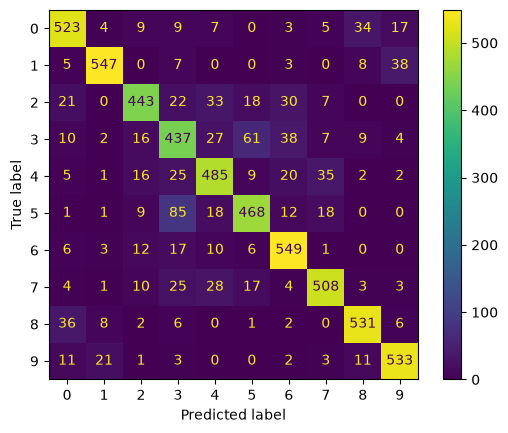

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_holdout,
    y_pred_classes
)
